In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.config_presets.tools.get_config import get_config


config = get_config('Daniel/Uncertainty_main')

endpoint_list = config['columns']['labels']

endpoint_list

src/config_presets/Base_config.yaml
src/config_presets/Daniel/Uncertainty_main.yaml


['Dysphagia_M06']

In [3]:

ALL_DFS_DICT = {
     "Dysphagia_M06" : {
        "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC Dysphagia PRIMA/20/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble PRIMA/Dysphagia_M06/all_predictions.csv", sep=';'),
        "TTA": pd.read_csv("/home/macraedc/UQ_results/TTA PRIMA/Dysphagia_M06/model_1/all_predictions.csv", sep=';'),
    },
   'Xerostomia_M06' : {
       "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC Xerostomia PRIMA/20/model_1/all_predictions.csv", sep=';'),
       "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble PRIMA/Xerostomia_M06/all_predictions.csv", sep=';'),
       "TTA": pd.read_csv("/home/macraedc/UQ_results/TTA PRIMA/Xerostomia_M06/model_1/all_predictions.csv", sep=';'),
   },
   'OS_2year_censored' : {
        "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC OS/10/model_1/all_predictions.csv", sep=';'),
        "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble/OS/all_predictions.csv", sep=';'),
        "TTA": pd.read_csv("/home/macraedc/UQ_results/TTA/OS/model_1/all_predictions.csv", sep=';'),
            },
    'LRC_2year_censored' : {
            "MC Dropout": pd.read_csv("/home/macraedc/UQ_results/Tune MC LRC/10/model_1/all_predictions.csv", sep=';'),
            "Deep Ensemble": pd.read_csv("/home/macraedc/UQ_results/Deep Ensemble/LRC/all_predictions.csv", sep=';'),
            "TTA": pd.read_csv("/home/macraedc/UQ_results/TTA/LRC/model_1/all_predictions.csv", sep=';'),
                },    
}

In [4]:
%load_ext autoreload
%autoreload 2

from src.uncertainty.metrics.mutual_information import mutual_information
from src.uncertainty.metrics.entropy import binary_entropy
from src.uncertainty.metrics.variance import variance


UQ_RESULTS_DICT = {
    "Dysphagia_M06": {},
    "Xerostomia_M06" : {},
    "OS_2year_censored": {},
    "LRC_2year_censored": {},
                   }

ENDPOINT_TYPES = {
    "Xerostomia_M06": "Binary",
    "Dysphagia_M06": "Binary",
    "OS_2year_censored": "Binary",
    "LRC_2year_censored": "Binary",
}


def compute_uncertainty_metrics_for_endpoint(df, endpoint):
#for endpoint in endpoint_list:
    df_UQ_results = pd.DataFrame(index=df.index)

    endpoint_pred_columns = [col for col in df.columns if 'pred' in col]

    all_endpoint_preds = df[endpoint_pred_columns]

    mean_endpoint_preds = all_endpoint_preds.mean(axis=1)

    df_UQ_results['Mean Prediction'] = mean_endpoint_preds
    df_UQ_results['PatientID']= df.PatientID

    if ENDPOINT_TYPES[endpoint] == "Binary":
        df_UQ_results['True Labels'] = df[endpoint + '_true']
    else:
        df_UQ_results['True Label Event'] = df[endpoint + '_event_true'].values
        df_UQ_results['True Months Event'] = df[endpoint + '_months_true'].values
        
    df_UQ_results['Mutual Information'] = mutual_information(all_endpoint_preds)
    df_UQ_results['Binary Entropy'] = binary_entropy(mean_endpoint_preds)
    df_UQ_results['Variance'] =  variance(all_endpoint_preds)

    return df_UQ_results


def compute_AUC_per_endpoint(df, endpoint):
    from sklearn.metrics import roc_auc_score

    if ENDPOINT_TYPES[endpoint] == "Binary":
        auc = roc_auc_score(df['True Labels'], df['Mean Prediction'])
    else:
        auc = roc_auc_score(df['True Label Event'], df['Mean Prediction'])

    return auc

for endpoint, dfs in ALL_DFS_DICT.items():

    for method, df_all_preds in dfs.items():

        df_UQ_results = compute_uncertainty_metrics_for_endpoint(df_all_preds, endpoint)
        UQ_RESULTS_DICT[endpoint][method] = df_UQ_results

        df_non_missing = df_UQ_results[df_UQ_results['True Labels'] != -1]

        auc = compute_AUC_per_endpoint(df_non_missing, endpoint)
        print(f"Endpoint: {endpoint}, Method: {method}, AUC: {auc:.2f}          ", len(df_non_missing))
        #print(len(df_non_missing))

    

#UQ_methods_list = list(ALL_DFS_DICT["Dysphagia_M06"].keys()) 
UQ_metrics_list = ["Binary Entropy", "Variance", "Mutual Information"]
UQ_methods_list = ['MC Dropout', 'Deep Ensemble', 'TTA'] # , "Conformal", "Conformal_2"]



Endpoint: Dysphagia_M06, Method: MC Dropout, AUC: 0.86           241
Endpoint: Dysphagia_M06, Method: Deep Ensemble, AUC: 0.87           241
Endpoint: Dysphagia_M06, Method: TTA, AUC: 0.80           241
Endpoint: Xerostomia_M06, Method: MC Dropout, AUC: 0.71           241
Endpoint: Xerostomia_M06, Method: Deep Ensemble, AUC: 0.72           241
Endpoint: Xerostomia_M06, Method: TTA, AUC: 0.71           241
Endpoint: OS_2year_censored, Method: MC Dropout, AUC: 0.74           82
Endpoint: OS_2year_censored, Method: Deep Ensemble, AUC: 0.73           82
Endpoint: OS_2year_censored, Method: TTA, AUC: 0.72           82
Endpoint: LRC_2year_censored, Method: MC Dropout, AUC: 0.62           78
Endpoint: LRC_2year_censored, Method: Deep Ensemble, AUC: 0.57           78
Endpoint: LRC_2year_censored, Method: TTA, AUC: 0.64           78


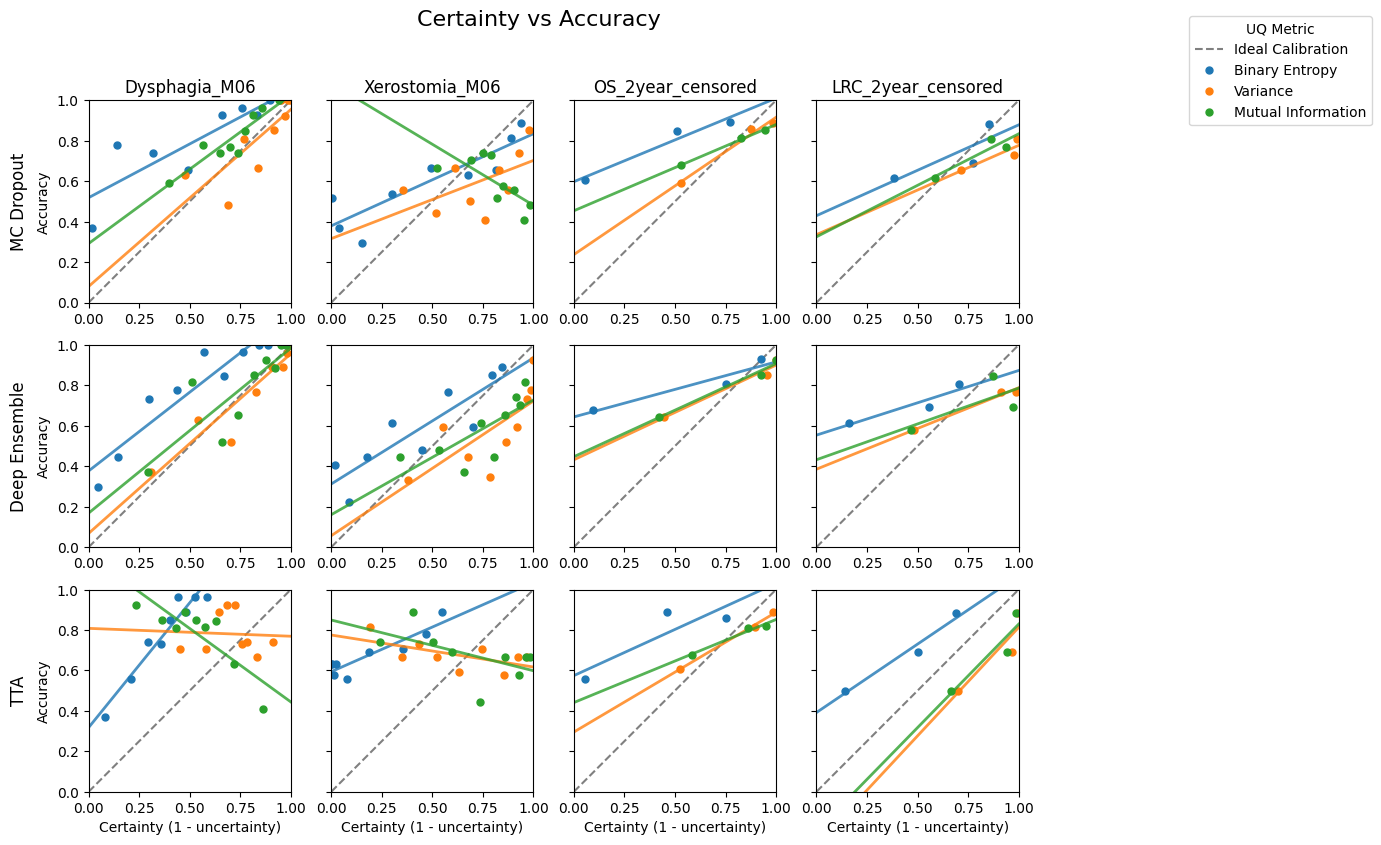

In [51]:
from src.uncertainty.visualisation.plotting_UQ import plot_nested_UQ

# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="error calibration", row_key="method", col_key="endpoint", N_bins=5)
# plt.show()

# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="prediction_calibration", row_key="method", 
#                      col_key="endpoint", N_bins=5, normalisation_method=None) # predictions
# plt.show()

fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="UQ_calibration", row_key="method", 
                     col_key="endpoint", N_bins=5, normalisation_method="minmax") # predictions
plt.show()

# fig = plot_nested_UQ(UQ_RESULTS_DICT, ENDPOINT_TYPES, UQ_methods_list, UQ_metrics_list, plot_type="sparsification", row_key="method", col_key="endpoint")
# plt.show()


In [43]:
# function to calculate the correlation between the UQ metric values and a model performance metric (e.g., accuracy or AUC)
from src.uncertainty.visualisation.calibration_plot import normalise_uncertainty_values
from sklearn.metrics import log_loss, roc_curve, roc_auc_score, accuracy_score
from src.evaluation.metrics.calibration import ACE

def calculate_correlation(UQ_results_dict, endpoint, method, UQ_metric, performance_metric):
    from scipy.stats import pearsonr, spearmanr

    df = UQ_results_dict[endpoint][method]

    df_UQ_no_missing_labels = df[df['True Labels'] != -1]
    true_labels = df_UQ_no_missing_labels['True Labels'].values
    mean_preds = df_UQ_no_missing_labels['Mean Prediction'].values


    
    UQ_values = df_UQ_no_missing_labels[UQ_metric]
    if UQ_metric == "Binary Entropy":
        UQ_metric_norm = UQ_values
    else:
        UQ_metric_norm = normalise_uncertainty_values(UQ_values, normalisation_method='minmax')

    aucs, bin_centers = [], []
    N_bins = len(mean_preds) // 25
    uq_bins = pd.qcut(UQ_metric_norm, N_bins, labels=False, duplicates='drop')
    performance_values = []
    for b in np.unique(uq_bins):
        idx = uq_bins == b

        if np.unique(true_labels[idx]).size == 2:
            thresh_value = 0.5
            score = accuracy_score(true_labels[idx], mean_preds[idx]>thresh_value)
            # score = roc_auc_score(true_labels[idx], mean_preds[idx])
            performance_values.append(score)
        else:
            performance_values.append(1)   

        bin_centers.append(1 - UQ_metric_norm[idx].mean())               
                
                

    pearson_corr, _ = pearsonr(bin_centers, performance_values)
    spearman_corr, _ = spearmanr(bin_centers, performance_values)

    ACE = 0
    for i in range(N_bins):
        abs_conf_dif = abs(performance_values[i] - bin_centers[i])
        ACE += abs_conf_dif
    ACE = ACE / N_bins

    
    # if method == "TTA" and UQ_metric == "Binary Entropy":
    #     print(UQ_values.min(), UQ_values.max())
    #     print(UQ_metric_norm.min(), UQ_metric_norm.max())
    #     plt.scatter(UQ_metric_norm, performance_values, alpha=0.3)
    #     #print(f"Endpoint: {endpoint}, Method: {method}, UQ Metric: {UQ_metric}, Pearson Corr: {pearson_corr:.2f}, Spearman Corr: {spearman_corr:.2f}")

    return ACE, pearson_corr, spearman_corr

UQ_endpoint_list = list(UQ_RESULTS_DICT.keys())
for endpoint in UQ_endpoint_list:
    for method in UQ_methods_list:
        for UQ_metric in UQ_metrics_list:
            ACE, pearson_corr, spearman_corr = calculate_correlation(UQ_RESULTS_DICT, endpoint, method, UQ_metric, "AUC")
            print(f"Endpoint: {endpoint}, Method: {method}, UQ Metric: {UQ_metric}, ACE: {ACE:.2f}") # , Pearson Corr: {pearson_corr:.2f}, Spearman Corr: {spearman_corr:.2f}")

Endpoint: Dysphagia_M06, Method: MC Dropout, UQ Metric: Binary Entropy, ACE: 0.26
Endpoint: Dysphagia_M06, Method: MC Dropout, UQ Metric: Variance, ACE: 0.08
Endpoint: Dysphagia_M06, Method: MC Dropout, UQ Metric: Mutual Information, ACE: 0.10
Endpoint: Dysphagia_M06, Method: Deep Ensemble, UQ Metric: Binary Entropy, ACE: 0.26
Endpoint: Dysphagia_M06, Method: Deep Ensemble, UQ Metric: Variance, ACE: 0.06
Endpoint: Dysphagia_M06, Method: Deep Ensemble, UQ Metric: Mutual Information, ACE: 0.09
Endpoint: Dysphagia_M06, Method: TTA, UQ Metric: Binary Entropy, ACE: 0.41
Endpoint: Dysphagia_M06, Method: TTA, UQ Metric: Variance, ACE: 0.16
Endpoint: Dysphagia_M06, Method: TTA, UQ Metric: Mutual Information, ACE: 0.36
Endpoint: Xerostomia_M06, Method: MC Dropout, UQ Metric: Binary Entropy, ACE: 0.19
Endpoint: Xerostomia_M06, Method: MC Dropout, UQ Metric: Variance, ACE: 0.19
Endpoint: Xerostomia_M06, Method: MC Dropout, UQ Metric: Mutual Information, ACE: 0.24
Endpoint: Xerostomia_M06, Method:

In [48]:
# function to calculate the correlation between the UQ metric values and a model performance metric (e.g., accuracy or AUC)
from src.uncertainty.visualisation.calibration_plot import normalise_uncertainty_values
from sklearn.metrics import log_loss, roc_curve, roc_auc_score, accuracy_score
from src.evaluation.metrics.calibration import ACE

def calculate_correlation(UQ_results_dict, endpoint, method, UQ_metric, performance_metric):
    from scipy.stats import pearsonr, spearmanr

    df = UQ_results_dict[endpoint][method]

    df_UQ_no_missing_labels = df[df['True Labels'] != -1]
    true_labels = df_UQ_no_missing_labels['True Labels'].values
    mean_preds = df_UQ_no_missing_labels['Mean Prediction'].values


    
    UQ_values = df_UQ_no_missing_labels[UQ_metric]
    if UQ_metric == "Binary Entropy":
        UQ_metric_norm = UQ_values
    else:
        UQ_metric_norm = normalise_uncertainty_values(UQ_values, normalisation_method='minmax')

   
                

    pearson_corr, _ = pearsonr(UQ_metric_norm,  np.abs(true_labels - mean_preds)**2)
    spearman_corr, _ = spearmanr(UQ_metric_norm,  np.abs(true_labels - mean_preds)**2)

    return pearson_corr, spearman_corr

UQ_endpoint_list = list(UQ_RESULTS_DICT.keys())
for endpoint in UQ_endpoint_list:
    for method in UQ_methods_list:
        for UQ_metric in UQ_metrics_list:
            pearson_corr, spearman_corr = calculate_correlation(UQ_RESULTS_DICT, endpoint, method, UQ_metric, "AUC")
            print(f"Endpoint: {endpoint}, Method: {method}, UQ Metric: {UQ_metric}, Pearson Corr: {pearson_corr:.2f}, Spearman Corr: {spearman_corr:.2f}")

Endpoint: Dysphagia_M06, Method: MC Dropout, UQ Metric: Binary Entropy, Pearson Corr: 0.37, Spearman Corr: 0.89
Endpoint: Dysphagia_M06, Method: MC Dropout, UQ Metric: Variance, Pearson Corr: 0.31, Spearman Corr: 0.87
Endpoint: Dysphagia_M06, Method: MC Dropout, UQ Metric: Mutual Information, Pearson Corr: 0.29, Spearman Corr: 0.68
Endpoint: Dysphagia_M06, Method: Deep Ensemble, UQ Metric: Binary Entropy, Pearson Corr: 0.47, Spearman Corr: 0.90
Endpoint: Dysphagia_M06, Method: Deep Ensemble, UQ Metric: Variance, Pearson Corr: 0.44, Spearman Corr: 0.87
Endpoint: Dysphagia_M06, Method: Deep Ensemble, UQ Metric: Mutual Information, Pearson Corr: 0.42, Spearman Corr: 0.79
Endpoint: Dysphagia_M06, Method: TTA, UQ Metric: Binary Entropy, Pearson Corr: 0.39, Spearman Corr: 0.84
Endpoint: Dysphagia_M06, Method: TTA, UQ Metric: Variance, Pearson Corr: 0.02, Spearman Corr: 0.18
Endpoint: Dysphagia_M06, Method: TTA, UQ Metric: Mutual Information, Pearson Corr: -0.26, Spearman Corr: -0.39
Endpoint